# EDA 8 - Case loactor map after eda 7



### EDA 7 companion figure — mechanism choropleth

Shades ALL London MSOAs by a Frame C mechanism classification that generalises the three case-study narratives, then overlays the seven
case MSOAs (black outline + label) as exemplars of their zones.
 
**Categories (mutually exclusive, from eda4 Frame C typology):**
- genuine cascade   
  - Typ_C_21 == Cascade-led  AND  Casc_Inflow_Share_21 >= 0.5
  - (affluent-inflow-led: the gentrification signature)
- exodus cascade    
  - Typ_C_21 == Cascade-led  AND  Casc_Inflow_Share_21 <  0.5
  - (outflow-driven: the COVID-era false-cascade signature)
- cascade->counter  
  - Typ_C_11 == Cascade-led  AND  Typ_C_21 == Counter-led
- other             
  - everything else (light grey fabric)
 
**Geo Harmonisation**
Camden 024/025 merge: E02000190 inherits the category of E02000189.
 
**Inputs:**  
london_msoa_2011.geojson  (any GeoJSON with MSOA11CD works)
eda4_results_for_phase3_20260626.csv

In [3]:
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PolyCollection
from matplotlib.lines import Line2D
from shapely.geometry import shape
from shapely.ops import unary_union

plt.rcParams['font.family'] = 'DejaVu Sans'

In [5]:
from pyprojroot import here

ROOT       = here()
sys.path.insert(0, str(ROOT))

DATA_DIR    = ROOT / 'data'
OUT_DIR     = ROOT / 'outputs' / 'case_study'
BOUNDARIES  = DATA_DIR / 'london_msoa_2011.geojson'
EDA4        = ROOT / 'outputs'/'eda4_results_for_phase3_20260626.csv'
OUT_PNG     = OUT_DIR / 'fig_case_locator_choropleth.png'

OUT_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
C_IN, C_EX, K_IN = '#c0392b', '#e8a7a0', '#6a51a3'
GREY = '#e9e7e2'

In [7]:
CAT_STYLE = {
    'genuine': dict(fc=C_IN,     alpha=0.95),
    'exodus':  dict(fc=C_EX,     alpha=0.95),
    'flip':    dict(fc=K_IN,     alpha=0.80),
    'other':   dict(fc=GREY,     alpha=1.00),
}

In [8]:
CASES = {
    'E02000191': 'Camden 026',
    'E02000873': 'Tower Hamlets 010',
    'E02000809': 'Southwark 003',
    'E02000561': 'Islington 008',
    'E02000957': 'Wandsworth 035',
    'E02000440': 'Harrow 008',
    'E02000461': 'Harrow 029',
}

In [9]:
LABEL_OFF = {
    'Camden 026':        (-0.105,  0.014),
    'Tower Hamlets 010': ( 0.095,  0.022),
    'Southwark 003':     ( 0.085, -0.048),
    'Islington 008':     ( 0.085,  0.036),
    'Wandsworth 035':    (-0.035, -0.058),
    'Harrow 008':        ( 0.082,  0.030),
    'Harrow 029':        (-0.090, -0.030),
}

In [10]:
INNER_LONDON_LADS = {
    'E09000007','E09000001','E09000011','E09000012','E09000013',
    'E09000014','E09000019','E09000020','E09000022','E09000023',
    'E09000025','E09000028','E09000030','E09000032','E09000033',
}

In [11]:
# ── classify ────────────────────────────────────────────────────────────
e4 = pd.read_csv(EDA4)
 
INFLOW_MIN = 0.25   # sits in the empirical gap (0.16 -> 0.31) among frame-robust cascades
 
def classify(r):
    if r['Typ_C_21'] == 'Cascade-led':
        robust    = r['Typ_A_21'] == 'Cascade-led'          # cascade under London frame too
        inflowled = r['Casc_Inflow_Share_21'] >= INFLOW_MIN # arm not overwhelmingly outflow
        return 'genuine' if (robust and inflowled) else 'exodus'
    if r['Typ_C_11'] == 'Cascade-led' and r['Typ_C_21'] == 'Counter-led':
        return 'flip'
    return 'other'
 
e4['mech'] = e4.apply(classify, axis=1)
cat = dict(zip(e4['msoa11cd'], e4['mech']))
cat['E02000190'] = cat.get('E02000189', 'other')     # Camden 024/025 merge
counts = e4['mech'].value_counts()

saved /Users/xing/Desktop/CASA/dissertation/outputs/case_study/fig_case_locator_choropleth.png
mech
other      731
exodus     182
flip        56
genuine     13


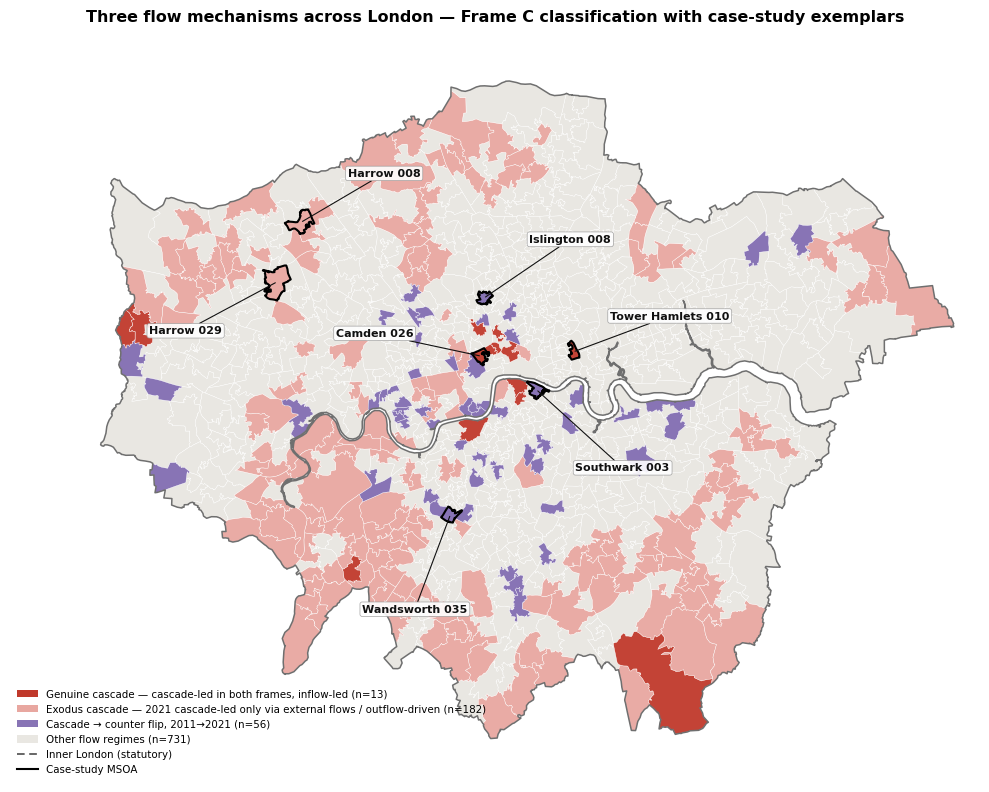

In [14]:
# ── geometry ────────────────────────────────────────────────────────────
gj = json.load(open(BOUNDARIES))
geoms, codes, lads = [], [], []
for ft in gj['features']:
    geoms.append(shape(ft['geometry']))
    codes.append(ft['properties']['MSOA11CD'])
    lads.append(ft['properties'].get('LAD11CD', ''))
 
# def rings(geom):
#     polys = geom.geoms if geom.geom_type == 'MultiPolygon' else [geom]
#     return [np.asarray(p.exterior.coords) for p in polys]

def rings(geom):
    # If it's a standard Polygon, wrap it in a list
    if geom.geom_type == 'Polygon':
        polys = [geom]
        
    # If it's a MultiPolygon, extract the constituent polygons
    elif geom.geom_type == 'MultiPolygon':
        polys = geom.geoms
        
    # If it's a GeometryCollection, filter out lines/points and keep only Polygons
    elif geom.geom_type == 'GeometryCollection':
        polys = [g for g in geom.geoms if g.geom_type == 'Polygon']
        
    # Catch-all for Points, LineStrings, or empty geometries
    else:
        polys = []
        
    return [np.asarray(p.exterior.coords) for p in polys]

######

fig, ax = plt.subplots(figsize=(10, 8))
 
# 1. choropleth, drawn per category so legend colours match exactly
for c in ('other', 'exodus', 'flip', 'genuine'):          # genuine on top
    st = CAT_STYLE[c]
    polys = [r for g, code in zip(geoms, codes)
             if cat.get(code, 'other') == c for r in rings(g)]
    ax.add_collection(PolyCollection(polys, facecolor=st['fc'],
                                     edgecolor='white', linewidth=0.3,
                                     alpha=st['alpha'], zorder=2))
 
# 2. Greater London + Inner London outlines
london = unary_union(geoms)
inner  = unary_union([g for g, l in zip(geoms, lads) if l in INNER_LONDON_LADS])
for r in rings(london):
    ax.plot(r[:, 0], r[:, 1], color='#6f6f6f', lw=1.1, zorder=5)
for r in rings(inner):
    ax.plot(r[:, 0], r[:, 1], color='#3d3d3d', lw=1.1, ls=(0, (5, 3)), zorder=5)
 
# 3. case MSOAs: black outline + leader label (exemplars of their zone)
for code, name in CASES.items():
    g = geoms[codes.index(code)]
    ax.add_collection(PolyCollection(rings(g), facecolor='none',
                                     edgecolor='black', linewidth=1.5, zorder=6))
    cx, cy = g.centroid.x, g.centroid.y
    dx, dy = LABEL_OFF[name]
    ax.annotate(name, xy=(cx, cy), xytext=(cx + dx, cy + dy),
                fontsize=8, fontweight='bold', color='#111',
                ha='center', va='center', zorder=8,
                arrowprops=dict(arrowstyle='-', color='#111', lw=0.8,
                                shrinkA=0, shrinkB=1),
                bbox=dict(boxstyle='round,pad=0.2', fc='white',
                          ec='#999', lw=0.5, alpha=0.9))
 
# 4. legend with live counts
handles = [
    mpatches.Patch(fc=C_IN,  label=f"Genuine cascade — cascade-led in both frames, inflow-led (n={counts.get('genuine',0)})"),
    mpatches.Patch(fc=C_EX,  label=f"Exodus cascade — 2021 cascade-led only via external flows / outflow-driven (n={counts.get('exodus',0)})"),
    mpatches.Patch(fc=K_IN, alpha=0.8,
                   label=f"Cascade \u2192 counter flip, 2011\u21922021 (n={counts.get('flip',0)})"),
    mpatches.Patch(fc=GREY,  label=f"Other flow regimes (n={counts.get('other',0)})"),
    Line2D([0], [0], color='#3d3d3d', lw=1.1, ls=(0, (5, 3)), label='Inner London (statutory)'),
    Line2D([0], [0], color='black', lw=1.5, label='Case-study MSOA'),
]
ax.legend(handles=handles, loc='lower left', fontsize=7.4, frameon=False,
          borderaxespad=0.3)
 
ax.set_title('Three flow mechanisms across London \u2014 Frame C classification with case-study exemplars',
             fontsize=11.5, fontweight='bold', pad=10)
ax.set_aspect(1.0 / np.cos(np.radians(51.5)))
ax.set_xlim(-0.60, 0.36); ax.set_ylim(51.26, 51.72)
ax.set_axis_off()
 
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150, bbox_inches='tight')
print(f'saved {OUT_PNG}')
print(counts.to_string())